## ***collecter les donnees ***

In [1]:
!pip install openmeteo-requests requests-cache retry-requests pandas numpy matplotlib seaborn plotly --quiet
import openmeteo_requests
import requests_cache
from retry_requests import retry
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')
print('imports ok')
LATITUDE=33.5731
LONGITUDE=-7.5898
VILLE="Casablanca, Maroc"
START_DATE="2019-01-01"
END_DATE="2024-12-31"

VARIABLES=[
    "temperature_2m_max",
    "temperature_2m_min",
    "precipitation_sum",
    "windspeed_10m_max",
    "shortwave_radiation_sum",
    "relative_humidity_2m_max",
    "relative_humidity_2m_min",
    "et0_fao_evapotranspiration"]
print(f"region:{VILLE}")
print(f"debut:{START_DATE}  fin:{END_DATE}")
print(f"nb variables:{len(VARIABLES)}")

cache_session=requests_cache.CachedSession('.cache', expire_after=3600)
retry_session=retry(cache_session,retries=5, backoff_factor=0.2)
openmeteo=openmeteo_requests.Client(session=retry_session)
params={
    "latitude":LATITUDE,
    "longitude":LONGITUDE,
    "start_date":START_DATE,
    "end_date":END_DATE,
    "daily":VARIABLES,
    "timezone":"Africa/Casablanca"
}
url="https://archive-api.open-meteo.com/v1/archive"
responses=openmeteo.weather_api(url, params=params)
response=responses[0]
print("connexion reussie")
print(f"coordonnees reelles :{response.Latitude()} ,{response.Longitude()}")
daily=response.Daily()

data={
    "date":pd.date_range(
        start=pd.to_datetime(daily.Time(),unit="s",utc=True),
        end=pd.to_datetime(daily.TimeEnd(),unit="s",utc=True),
        freq=pd.Timedelta(seconds=daily.Interval()),
        inclusive="left"
    ),
    "temp_max":daily.Variables(0).ValuesAsNumpy(),
    "temp_min":daily.Variables(1).ValuesAsNumpy(),
    "precipitation":daily.Variables(2).ValuesAsNumpy(),
    "wind_speed_max":daily.Variables(3).ValuesAsNumpy(),
    "radiation_sum":daily.Variables(4).ValuesAsNumpy(),
    "humidity_max":daily.Variables(5).ValuesAsNumpy(),
    "humidity_min":daily.Variables(6).ValuesAsNumpy(),
    "evapotranspiration":daily.Variables(7).ValuesAsNumpy()
}

df=pd.DataFrame(data)
df["date"]=pd.to_datetime(df["date"]).dt.normalize()
df=df.set_index("date")
df=df.loc['2019-01-01':'2024-12-31']
df["temp_mean"]=(df["temp_max"] + df["temp_min"]) / 2
df["humidity_mean"]=(df["humidity_max"] + df["humidity_min"]) / 2
print(f"dataset cree:{df.shape[0]} jours x {df.shape[1]} variables")
print(f"periode:{df.index.min().date()} au {df.index.max().date()}")
val_manq=df.isnull().sum()
if val_manq.sum()==0:
    print("aucune valeur manquante")
else:
    print(val_manq[val_manq > 0])

print(df.describe().round(2))
df.to_csv("climate_casablanca_2019_2024.csv")
print("dataset sauvegarde")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.9/208.9 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 771.3/771.3 kB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.1/128.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.0/396.0 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 37.2 MB/s eta 0:00:00
imports ok
region:Casablanca, Maroc
debut:2019-01-01  fin:2024-12-31
nb variables:8
connexion reussie
coordonnees reelles :33.56766128540039 ,-7.583648681640625
dataset cree:2191 jours x 10 variables
periode:2019-01-01 au 2024-12-30
aucune valeur manquante
       temp_max  temp_min  precipitation  wind_speed_max  radiation_sum  \
count   2191.00   2191.00        2191.00         2191.00        2191.00   
mean      22.47     14.82           0

## ***Visualisation des donnees ***

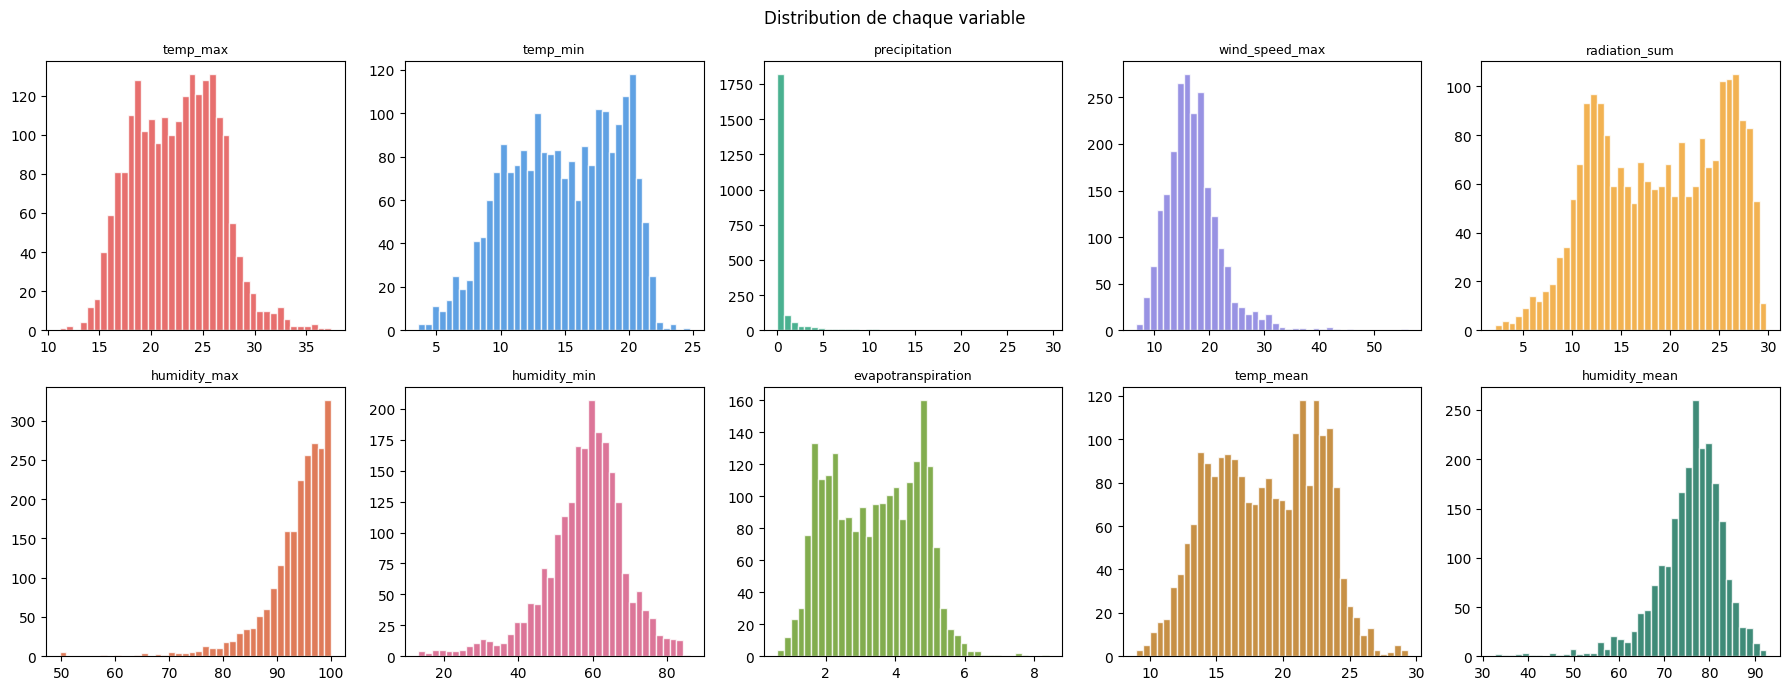

In [2]:
cols = df.columns.tolist()
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()
colors = ['#E24B4A','#378ADD','#1D9E75','#7F77DD','#EF9F27',
          '#D85A30','#D4537E','#639922','#BA7517','#0F6E56']
for i, col in enumerate(cols):
    axes[i].hist(df[col],bins=40,color=colors[i],alpha=0.8,edgecolor='white')
    axes[i].set_title(col,fontsize=9)
    axes[i].set_xlabel("")
plt.suptitle("Distribution de chaque variable")
plt.tight_layout()
plt.show()

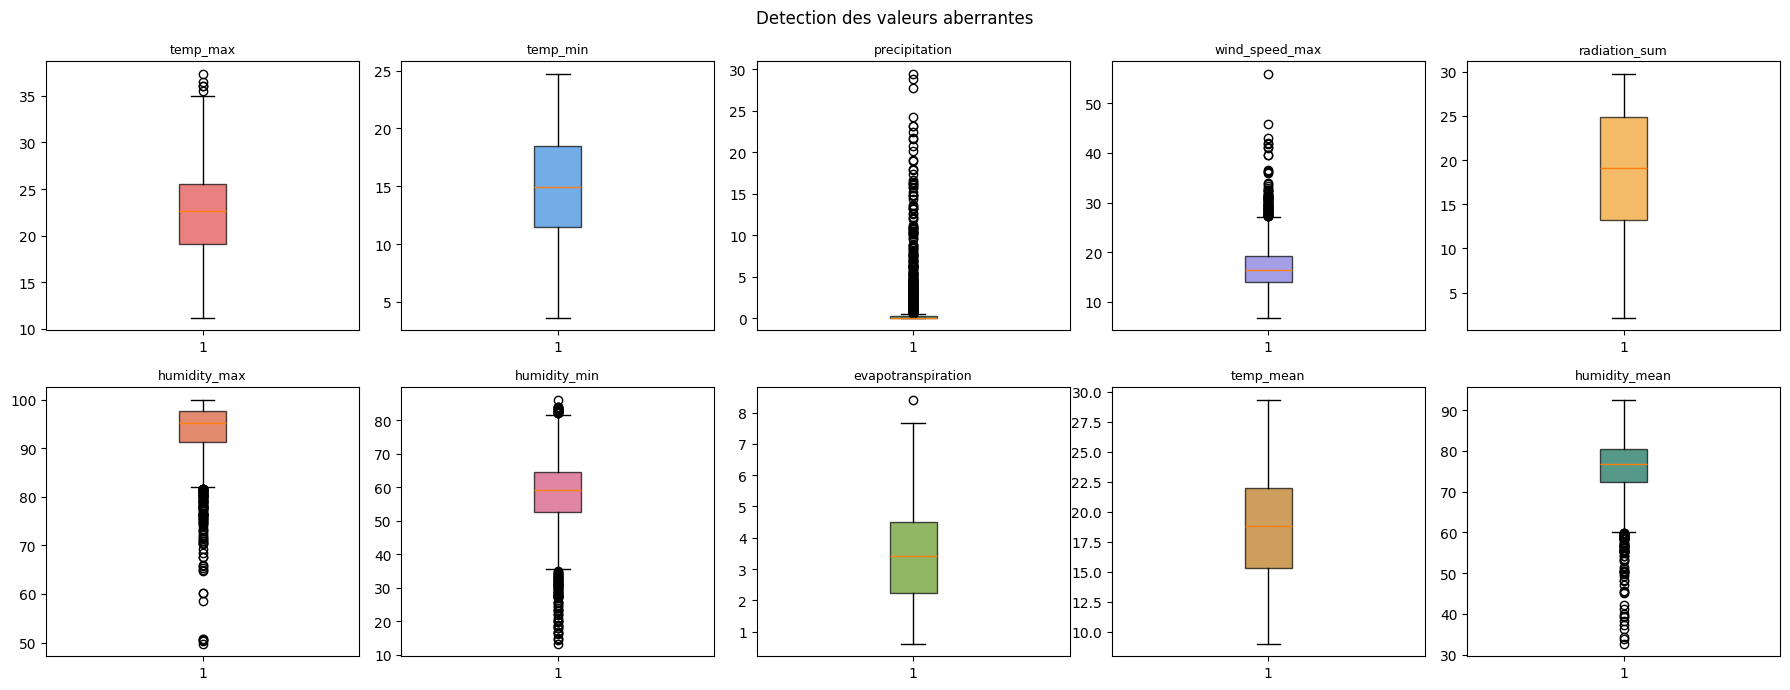

outlierstemp_max                 :   5(0.23%)
pas d'outlierstemp_min                 
outliersprecipitation            : 429(19.58%)
outlierswind_speed_max           :  82(3.74%)
pas d'outliersradiation_sum            
outliershumidity_max             : 104(4.75%)
outliershumidity_min             : 104(4.75%)
outliersevapotranspiration       :   1(0.05%)
pas d'outlierstemp_mean                
outliershumidity_mean            :  80(3.65%)


In [3]:
fig,axes=plt.subplots(2,5,figsize=(18, 7))
axes=axes.flatten()
for i,col in enumerate(cols):
    axes[i].boxplot(df[col].dropna(),patch_artist=True,
                    boxprops=dict(facecolor=colors[i],alpha=0.7))
    axes[i].set_title(col,fontsize=9)
plt.suptitle("Detection des valeurs aberrantes")
plt.tight_layout()
plt.show()
for col in df.columns:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    n_out=((df[col]<Q1-1.5*IQR) | (df[col]>Q3+1.5*IQR)).sum()
    pct=100*n_out/len(df)
    if pct>0:
        print(f"outliers{col:<25}:{n_out:>4}({pct:.2f}%)")
    else:
        print(f"pas d'outliers{col:<25}")

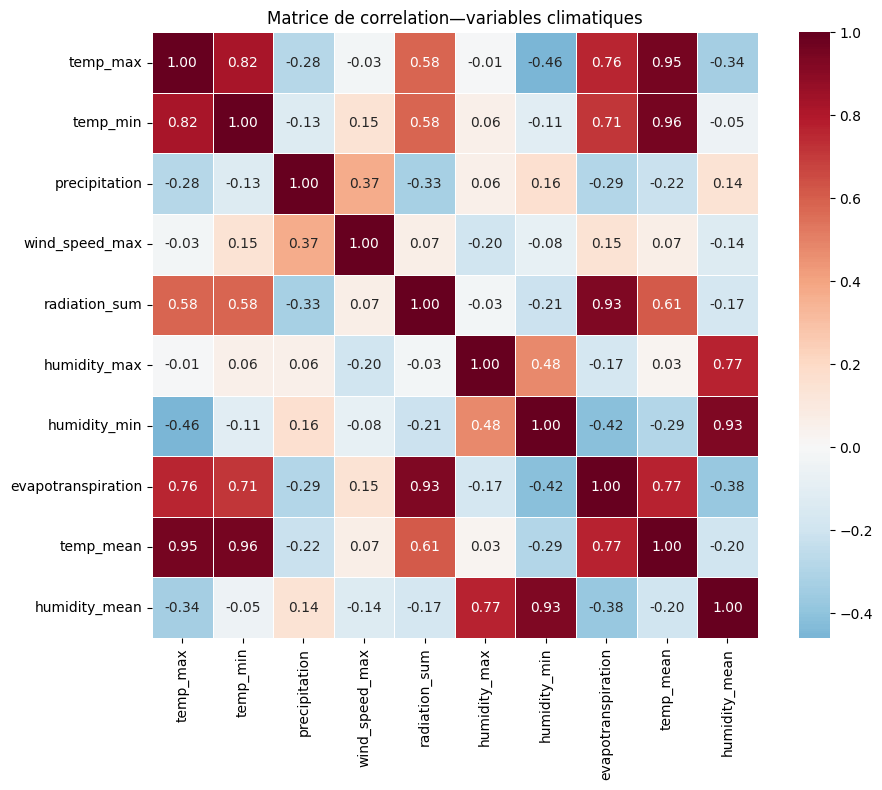

correlation avec temp_max:
temp_mean                 +0.95
temp_min                  +0.82
evapotranspiration        +0.76
radiation_sum             +0.58
humidity_min              -0.46
humidity_mean             -0.34
precipitation             -0.28
wind_speed_max            -0.03
humidity_max              -0.01


In [4]:
corr=df.corr().round(2)
plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True,fmt=".2f",cmap='RdBu_r',center=0,
            linewidths=0.5,square=True)
plt.title("Matrice de correlation—variables climatiques")
plt.tight_layout()
plt.show()
print("correlation avec temp_max:")
corr_target=df.corr()["temp_max"].drop("temp_max").sort_values(key=abs,ascending=False)
for var,val in corr_target.items():
    sign = "+" if val > 0 else "-"
    print(f"{var:25} {sign}{abs(val):.2f}")

# ***Prétraitement ***

In [5]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import joblib
df.index=pd.to_datetime(df.index).tz_localize(None)
df=df.sort_index()
df_clean=df.copy()

In [6]:
split_idx=int(len(df_clean)*0.8)
df_train=df_clean.iloc[:split_idx].copy()
df_test=df_clean.iloc[split_idx:].copy()

print(f"train:{df_train.index[0].date()}a{df_train.index[-1].date()}({len(df_train)}jours)")
print(f"test:{df_test.index[0].date()}a{df_test.index[-1].date()}({len(df_test)}jours)")

train:2019-01-01a2023-10-18(1752jours)
test:2023-10-19a2024-12-30(439jours)


In [7]:

cols_mm=['precipitation', 'wind_speed_max']
cols_std=[c for c in df_clean.columns if c not in cols_mm]
scaler_std=StandardScaler()
scaler_std.fit(df_train[cols_std])
df_std=df_clean.copy()
df_std[cols_std]=scaler_std.transform(df_clean[cols_std])
scaler_mm=MinMaxScaler()
scaler_mm.fit(df_train[cols_mm])
df_mm=df_clean.copy()
df_mm[cols_mm]=scaler_mm.transform(df_clean[cols_mm])

In [8]:
df_feat=df_clean.copy()
for lag in [1,3,7,14]:
    df_feat[f'tmax_lag{lag}']=df_feat['temp_max'].shift(lag)
    df_feat[f'precip_lag{lag}']=df_feat['precipitation'].shift(lag)
    df_feat[f'hum_lag{lag}']=df_feat['humidity_mean'].shift(lag)
for w in [7,30]:
    df_feat[f'tmax_moy{w}']= df_feat['temp_max'].rolling(w).mean()
    df_feat[f'tmax_std{w}']= df_feat['temp_max'].rolling(w).std()
    df_feat[f'precip_sum{w}']= df_feat['precipitation'].rolling(w).sum()
    df_feat[f'rad_moy{w}']= df_feat['radiation_sum'].rolling(w).mean()
df_feat['mois']=df_feat.index.month
df_feat['jour_annee']=df_feat.index.dayofyear
df_feat['semaine']=df_feat.index.isocalendar().week.astype(int)
df_feat['mois_sin']=np.sin(2*np.pi*df_feat['mois']/12)
df_feat['mois_cos']=np.cos(2*np.pi*df_feat['mois']/12)
df_feat['jour_sin']=np.sin(2*np.pi*df_feat['jour_annee']/365)
df_feat['jour_cos']=np.cos(2*np.pi*df_feat['jour_annee']/365)
def get_saison(m):
    if m in [12,1,2]:return 'Hiver'
    elif m in [3,4,5]:return 'Printemps'
    elif m in [6,7,8]:return 'Ete'
    else:return 'Automne'
df_feat['saison']=df_feat['mois'].map(get_saison)

n_avant=len(df_feat)
df_feat=df_feat.dropna()
print(f"df_feat:{df_feat.shape}  |  lignes supprimees:{n_avant-len(df_feat)}")

df_feat:(2162, 38)  |  lignes supprimees:29


In [9]:
def check_outliers(df, cols):
    for col in cols:
        Q1=df[col].quantile(0.25)
        Q3=df[col].quantile(0.75)
        IQR=Q3-Q1
        n=((df[col]<Q1-1.5*IQR) | (df[col]>Q3+1.5*IQR)).sum()
        print(f"{col:<25}:{n:>4} outliers ({100*n/len(df):.1f}%)")

check_outliers(df_feat,['temp_max','precipitation','wind_speed_max','humidity_mean'])

temp_max                 :   5 outliers (0.2%)
precipitation            : 424 outliers (19.6%)
wind_speed_max           :  82 outliers (3.8%)
humidity_mean            :  83 outliers (3.8%)


In [10]:
def indice_risque(row):
    score = 0
    if row['temp_max']>35:score += 40
    elif row['temp_max']>30:score += 20
    elif row['temp_max']>27:score += 10
    if row['precipitation']>15:score += 30
    elif row['precipitation']>5:score += 15
    elif row['precipitation']>1:score += 5
    if row['wind_speed_max']>40:score += 20
    elif row['wind_speed_max']>25:score += 10
    if row['humidity_mean']<45:score += 10
    elif row['humidity_mean']<55:score += 5
    label='Danger' if score >= 50 else ('Attention' if score >= 20 else 'Normal')
    return pd.Series({'risk_score':score,'risk_label': label})

df_feat[['risk_score','risk_label']]=df_feat.apply(indice_risque,axis=1)

dist=df_feat['risk_label'].value_counts()
print(f"Normal:{dist.get('Normal',0):>4}({100*dist.get('Normal',0)/len(df_feat):.1f}%)")
print(f"Attention:{dist.get('Attention',0):>4}({100*dist.get('Attention',0)/len(df_feat):.1f}%)")
print(f"Danger:{dist.get('Danger',0):>4}({100*dist.get('Danger',0)/len(df_feat):.1f}%)")

Normal:2031(93.9%)
Attention: 130(6.0%)
Danger:   1(0.0%)


# ***visualisation apres***

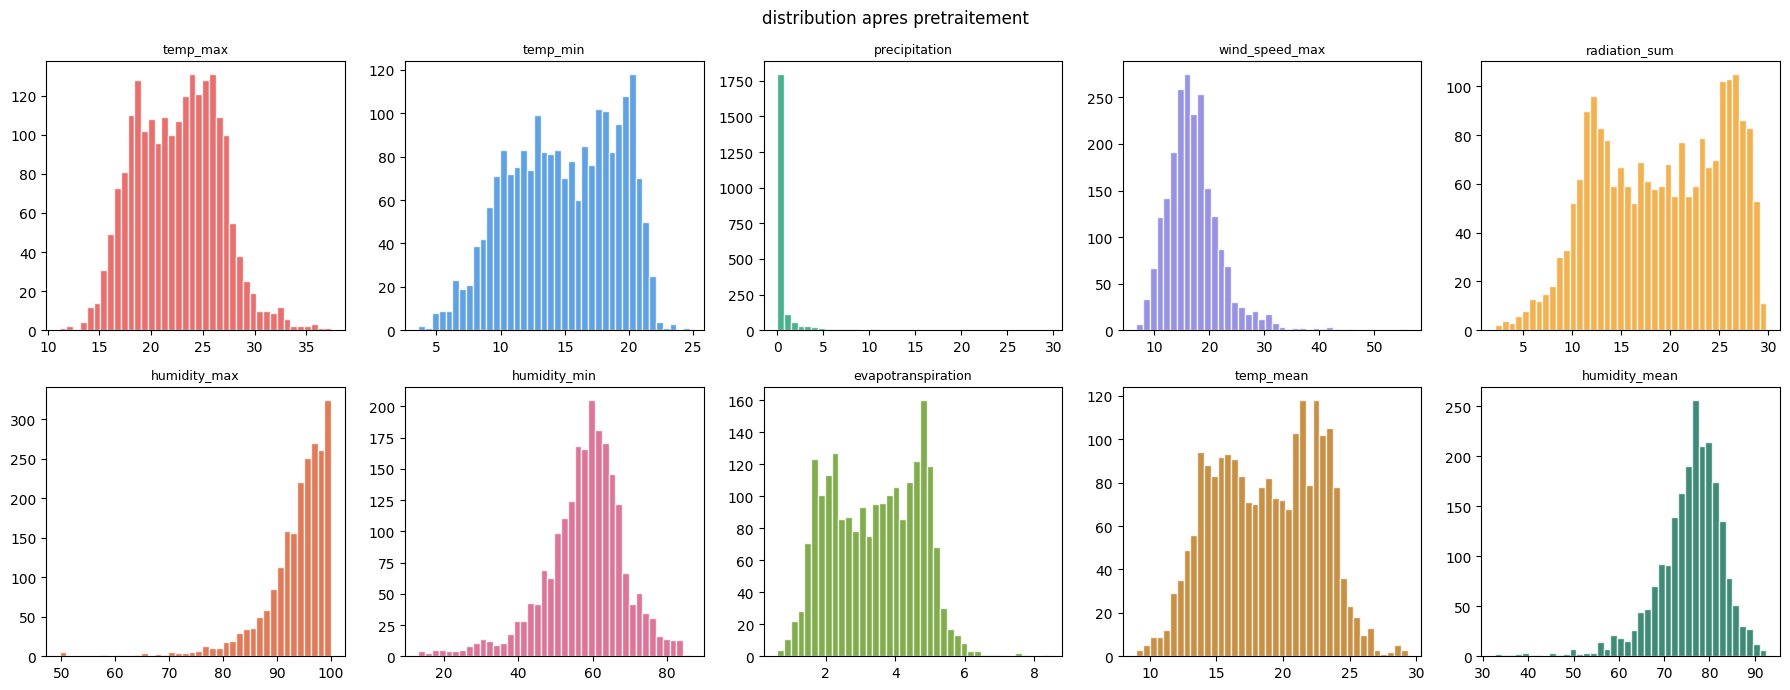

In [11]:
fig, axes=plt.subplots(2, 5, figsize=(18, 7))
axes=axes.flatten()
for i,col in enumerate(df_feat.columns[:10]):
    axes[i].hist(df_feat[col],bins=40,color=colors[i],alpha=0.8,edgecolor='white')
    axes[i].set_title(col,fontsize=9)
plt.suptitle("distribution apres pretraitement")
plt.tight_layout()
plt.show()

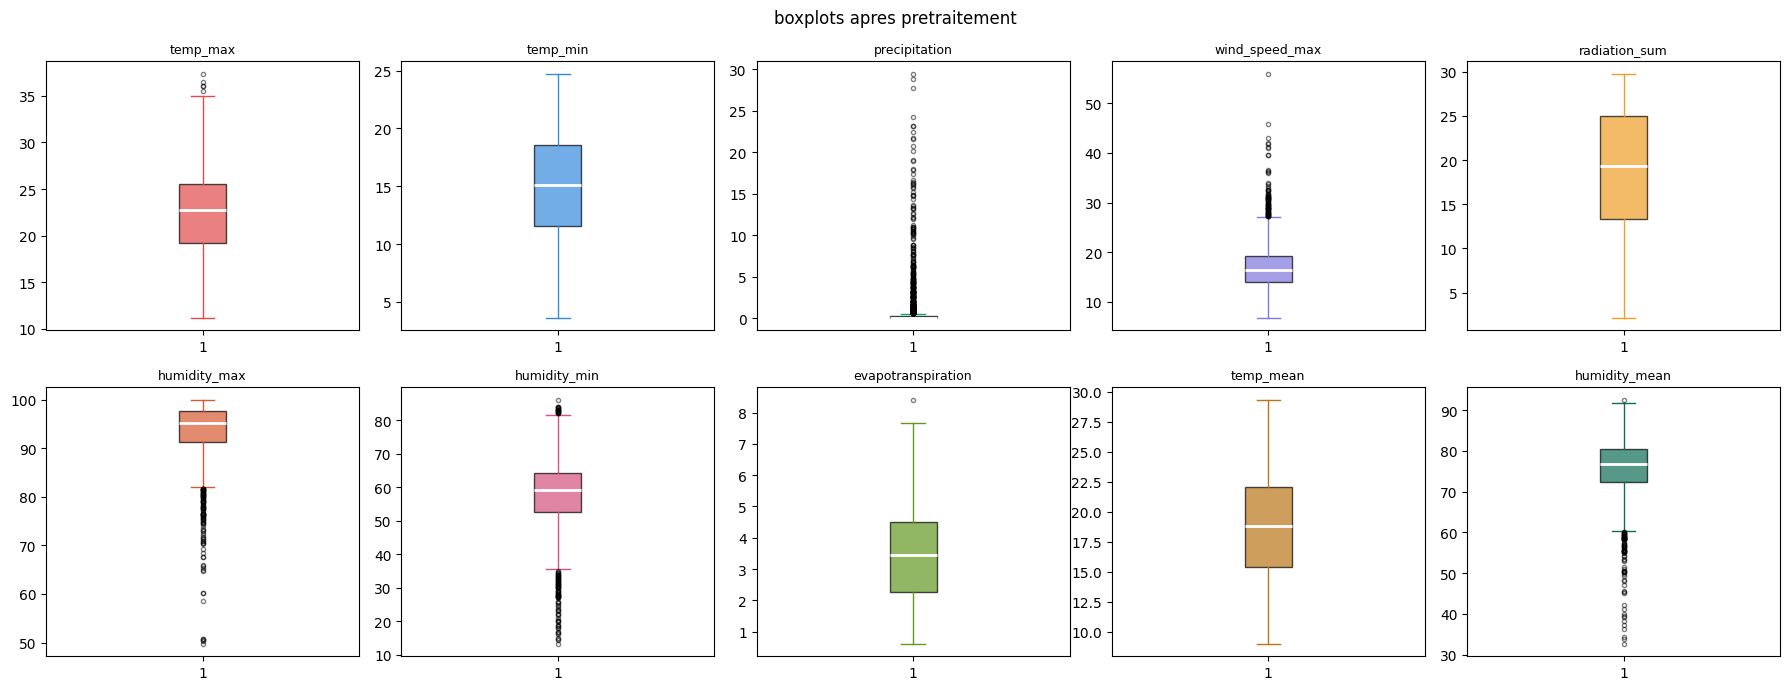

In [12]:
fig,axes=plt.subplots(2,5,figsize=(18,7))
axes=axes.flatten()
for i,col in enumerate(df_feat.columns[:10]):
    axes[i].boxplot(df_feat[col].dropna(),patch_artist=True,
                    boxprops=dict(facecolor=colors[i],alpha=0.7),
                    medianprops=dict(color='white',linewidth=2),
                    whiskerprops=dict(color=colors[i]),
                    capprops=dict(color=colors[i]),
                    flierprops=dict(marker='o',color=colors[i],markersize=3,alpha=0.5))
    axes[i].set_title(col,fontsize=9)
plt.suptitle("boxplots apres pretraitement")
plt.tight_layout()
plt.show()

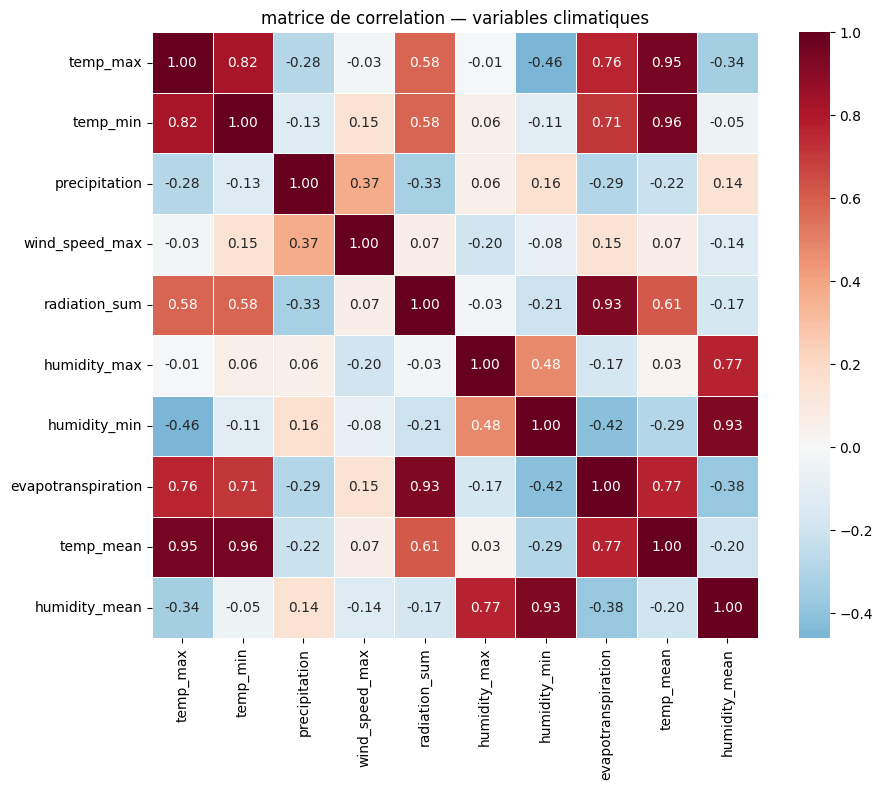

In [13]:
corr=df.corr().round(2)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True,fmt=".2f",cmap='RdBu_r',center=0,
            linewidths=0.5,square=True)
plt.title("matrice de correlation — variables climatiques")
plt.tight_layout()
plt.show()

# ***les modeles supervisée ***

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error
from xgboost import XGBRegressor
df_feat.to_csv("casablanca_features.csv")
joblib.dump(scaler_std, 'scaler_std.pkl')
df_feat=pd.read_csv("casablanca_features.csv",index_col=0,parse_dates=True)
scaler_std=joblib.load('scaler_std.pkl')
print(f"df_feat:{df_feat.shape}")
cols_exclues=['temp_max','temp_mean','risk_label','saison','season']
features_cols=[c for c in df_feat.columns if c not in cols_exclues and df_feat[c].dtype!='object']
print(f"features:{len(features_cols)}")
SPLIT_DATE='2023-10-18'
df_train=df_feat[df_feat.index<=SPLIT_DATE]
df_test=df_feat[df_feat.index>SPLIT_DATE]
X_train,y_train=df_train[features_cols],df_train['temp_max']
X_test,y_test=df_test[features_cols],df_test['temp_max']
print(f"train:{len(X_train)}jours  |  test:{len(X_test)}jours")
def eval_model(nom, y_test, y_pred):
    mse=mean_squared_error(y_test, y_pred)
    rmse=np.sqrt(mse)
    mae=mean_absolute_error(y_test, y_pred)
    r2=r2_score(y_test, y_pred)
    mape=np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    medae=median_absolute_error(y_test, y_pred)
    print(f"\n{nom}")
    print(f"MSE:{mse:.3f}")
    print(f"RMSE:{rmse:.3f} C")
    print(f"MAE:{mae:.3f} C")
    print(f"R2:{r2:.4f}")
    print(f"MAPE:{mape:.2f}%")
    print(f"MedAE:{medae:.3f}")
    return {'mse':mse,'rmse':rmse,'mae':mae,
            'r2':r2,'mape':mape,'medae':medae}

df_feat:(2162, 40)
features:36
train:1723jours  |  test:439jours



Linear Regression
MSE:1.865
RMSE:1.366 C
MAE:0.960 C
R2:0.8541
MAPE:4.28%
MedAE:0.681


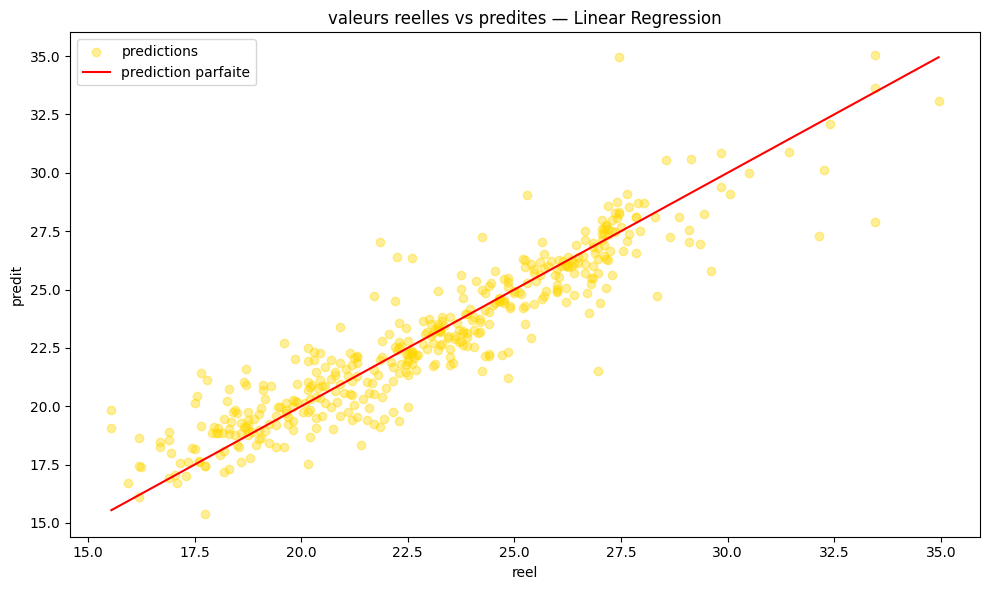

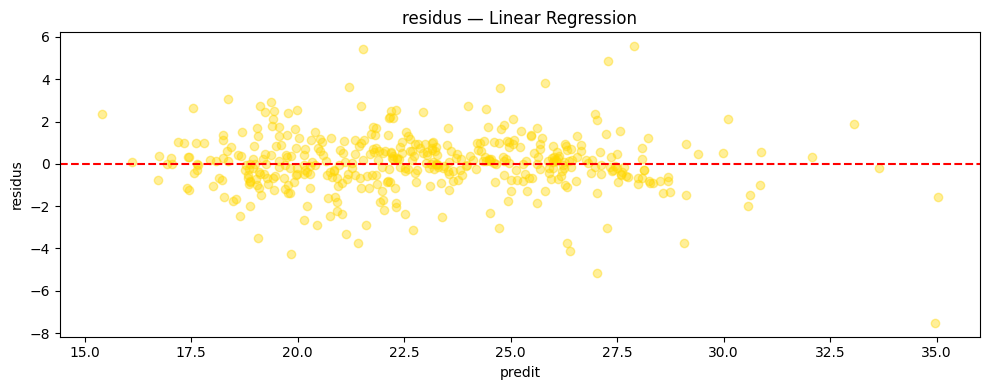

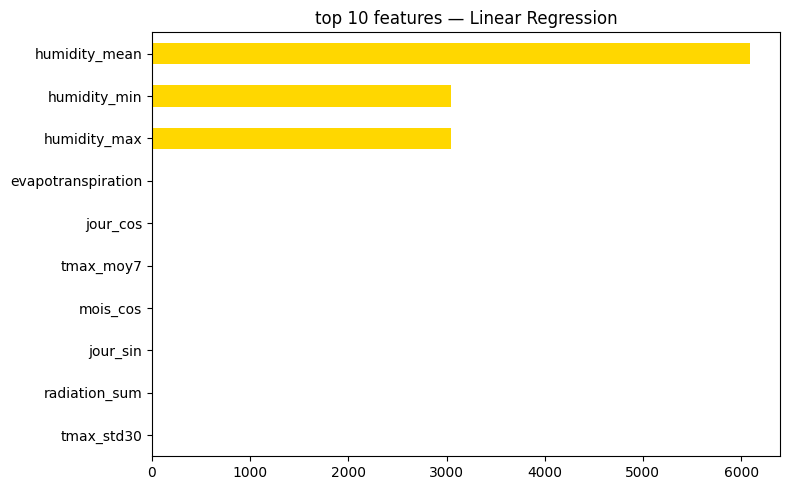

In [16]:
lr_model=LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred=lr_model.predict(X_test)
lr_res=eval_model('Linear Regression',y_test,lr_pred)
plt.figure(figsize=(10, 6))
plt.scatter(y_test,lr_pred,alpha=0.4,color='gold',label='predictions')
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],
         color='red',label='prediction parfaite')
plt.title("valeurs reelles vs predites — Linear Regression")
plt.xlabel("reel");plt.ylabel("predit");plt.legend()
plt.tight_layout();plt.show()
plt.figure(figsize=(10, 4))
plt.scatter(lr_pred, y_test - lr_pred,alpha=0.4,color='gold')
plt.axhline(0, color='red',linestyle='--')
plt.title("residus — Linear Regression")
plt.xlabel("predit");plt.ylabel("residus")
plt.tight_layout();plt.show()
coefs=pd.Series(np.abs(lr_model.coef_),index=features_cols).sort_values(ascending=True).tail(10)
plt.figure(figsize=(8,5))
coefs.plot(kind='barh',color='gold')
plt.title("top 10 features — Linear Regression")
plt.tight_layout();plt.show()

meilleurs params RF:{'max_depth': 15, 'min_samples_leaf': 2, 'n_estimators': 200}

Random Forest
MSE:2.541
RMSE:1.594 C
MAE:1.059 C
R2:0.8012
MAPE:4.78%
MedAE:0.709


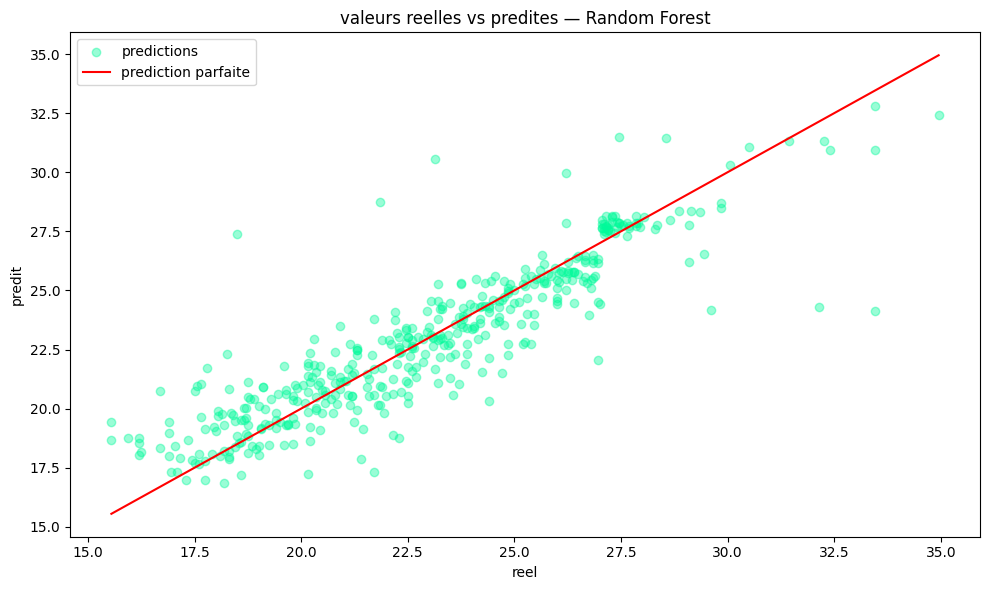

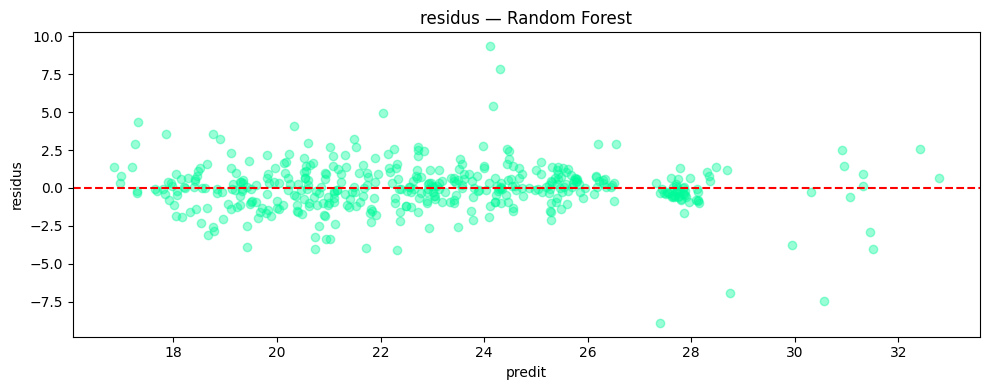

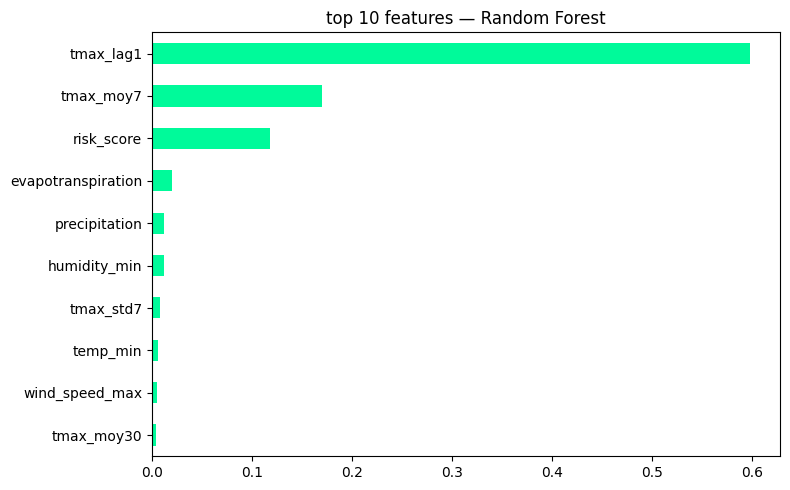

In [17]:
rf_param={'n_estimators': [100, 200], 'max_depth': [10, 15], 'min_samples_leaf':[1,2]}
grid_rf=GridSearchCV(RandomForestRegressor(random_state=42,n_jobs=-1),
                        rf_param,cv=5,scoring='r2',n_jobs=-1)
grid_rf.fit(X_train, y_train)
print(f"meilleurs params RF:{grid_rf.best_params_}")
rf_model=grid_rf.best_estimator_
rf_pred=rf_model.predict(X_test)
rf_res=eval_model('Random Forest',y_test,rf_pred)
plt.figure(figsize=(10, 6))
plt.scatter(y_test,rf_pred,alpha=0.4,color='#00FA9A',label='predictions')
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],color='red',label='prediction parfaite')
plt.title("valeurs reelles vs predites — Random Forest")
plt.xlabel("reel");plt.ylabel("predit");plt.legend()
plt.tight_layout();plt.show()
plt.figure(figsize=(10,4))
plt.scatter(rf_pred, y_test-rf_pred,alpha=0.4,color='#00FA9A')
plt.axhline(0,color='red',linestyle='--')
plt.title("residus — Random Forest")
plt.xlabel("predit");plt.ylabel("residus")
plt.tight_layout();plt.show()
importances_rf=pd.Series(rf_model.feature_importances_,index=features_cols).sort_values(ascending=True).tail(10)
plt.figure(figsize=(8,5))
importances_rf.plot(kind='barh',color='#00FA9A')
plt.title("top 10 features — Random Forest")
plt.tight_layout();plt.show()

meilleurs params XGB:{'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 300}

XGBoost
MSE:1.776
RMSE:1.333 C
MAE:0.938 C
R2:0.8610
MAPE:4.25%
MedAE:0.653


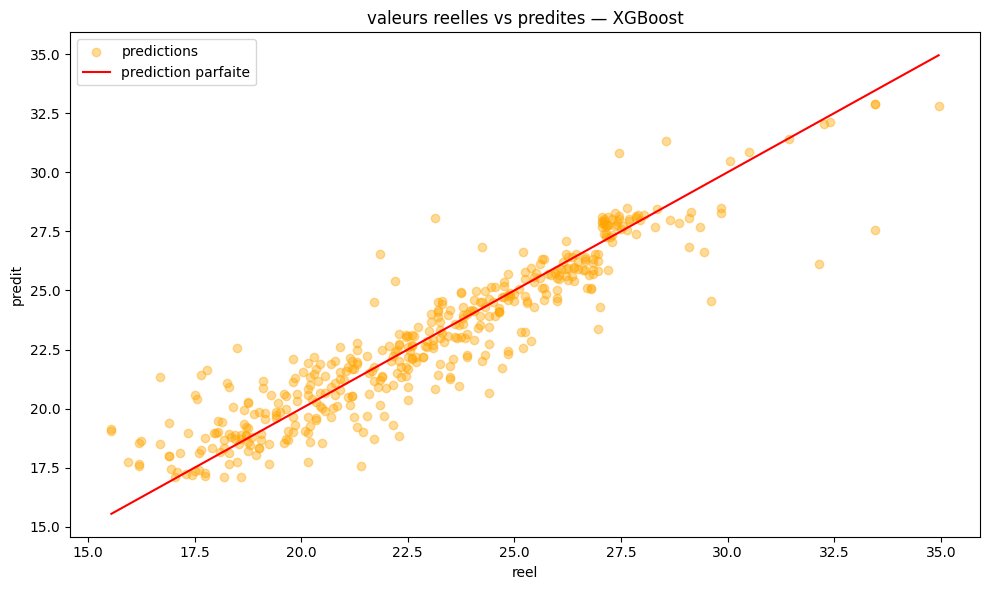

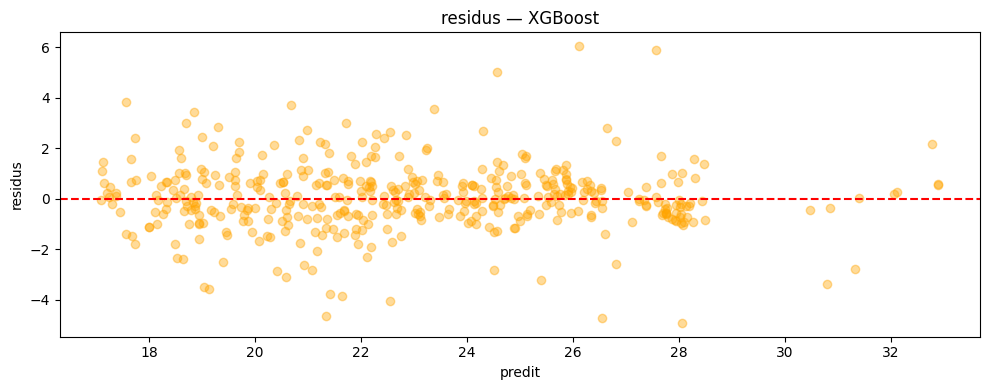

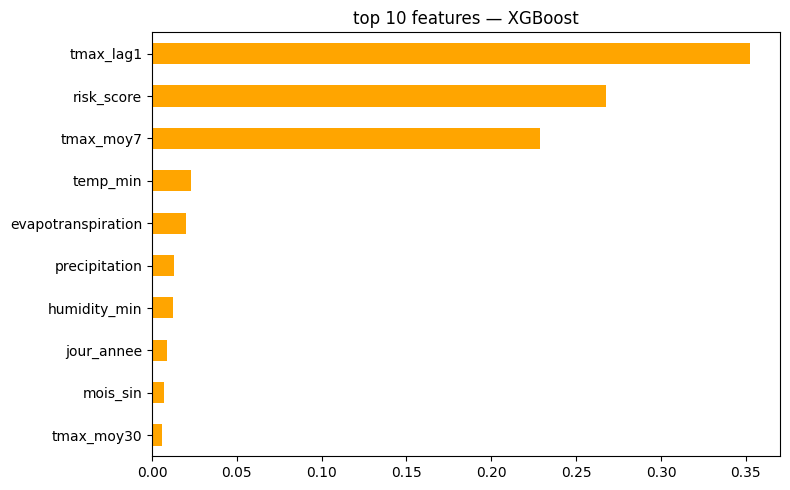

In [18]:
xgb_param ={'n_estimators':[100,200,300],'max_depth':[4,6,8],'learning_rate':[0.01,0.05,0.1]}
grid_xgb  = GridSearchCV(XGBRegressor(random_state=42, verbosity=0),xgb_param,cv=5,scoring='r2')
grid_xgb.fit(X_train, y_train)
print(f"meilleurs params XGB:{grid_xgb.best_params_}")
xgb_model=grid_xgb.best_estimator_
xgb_pred=xgb_model.predict(X_test)
xgb_res=eval_model('XGBoost', y_test, xgb_pred)
plt.figure(figsize=(10,6))
plt.scatter(y_test, xgb_pred, alpha=0.4, color='orange', label='predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', label='prediction parfaite')
plt.title("valeurs reelles vs predites — XGBoost")
plt.xlabel("reel");plt.ylabel("predit");plt.legend()
plt.tight_layout();plt.show()
plt.figure(figsize=(10,4))
plt.scatter(xgb_pred,y_test - xgb_pred,alpha=0.4,color='orange')
plt.axhline(0,color='red',linestyle='--')
plt.title("residus — XGBoost")
plt.xlabel("predit");plt.ylabel("residus")
plt.tight_layout();plt.show()
importances_xgb = pd.Series(xgb_model.feature_importances_,index=features_cols).sort_values(ascending=True).tail(10)
plt.figure(figsize=(8,5))
importances_xgb.plot(kind='barh',color='orange')
plt.title("top 10 features — XGBoost")
plt.tight_layout();plt.show()


In [19]:
noms=['Linear Regression','Random Forest','XGBoost']
resultats = [lr_res, rf_res, xgb_res]
print("\n"+"=")
print(f"{'modele':<20}{'MAE':>7}{'RMSE':>7}{'R2':>7}{'MAPE':>8}")
print()
for nom, res in zip(noms, resultats):
    print(f"{nom:<20} {res['mae']:>7.3f} {res['rmse']:>7.3f} {res['r2']:>7.4f} {res['mape']:>7.2f}%")
print()
meilleur=noms[np.argmax([r['r2'] for r in resultats])]
print(f"\nmeilleur modele:{meilleur}")


=
modele                  MAE   RMSE     R2    MAPE

Linear Regression      0.960   1.366  0.8541    4.28%
Random Forest          1.059   1.594  0.8012    4.78%
XGBoost                0.938   1.333  0.8610    4.25%


meilleur modele:XGBoost


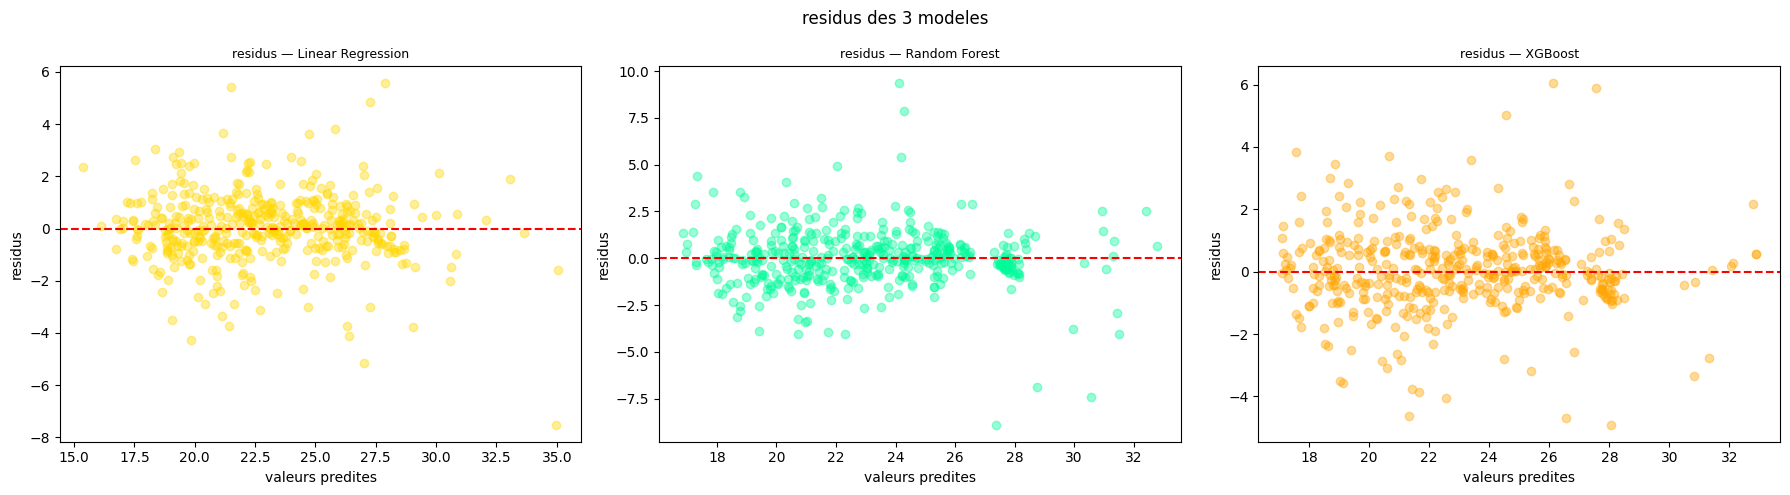

In [20]:
noms=['Linear Regression', 'Random Forest', 'XGBoost']
preds=[lr_pred, rf_pred, xgb_pred]
colors=['gold', '#00FA9A','orange']
fig,axes=plt.subplots(1,3,figsize=(18, 5))
for i,(nom, pred, col) in enumerate(zip(noms,preds,colors)):
    residus=y_test-pred
    axes[i].scatter(pred, residus,alpha=0.4,color=col)
    axes[i].axhline(0,color='red',linestyle='--')
    axes[i].set_title(f"residus — {nom}",fontsize=9)
    axes[i].set_xlabel("valeurs predites")
    axes[i].set_ylabel("residus")
plt.suptitle("residus des 3 modeles")
plt.tight_layout()
plt.show()

In [21]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors
print('imports ok')

imports ok


In [22]:
df_feat = pd.read_csv('casablanca_features.csv', index_col=0, parse_dates=True)
print(f"donnees chargees : {df_feat.shape}")
features_cluster=['temp_max','temp_min','precipitation','wind_speed_max','radiation_sum', 'humidity_max', 'humidity_min','humidity_mean', 'evapotranspiration']
X_cluster=df_feat[features_cluster].dropna()
print(f"lignes:{len(X_cluster)}")
scaler_cluster=StandardScaler()
X_scaled=scaler_cluster.fit_transform(X_cluster)

donnees chargees : (2162, 40)
lignes:2162


## ***k_means ***

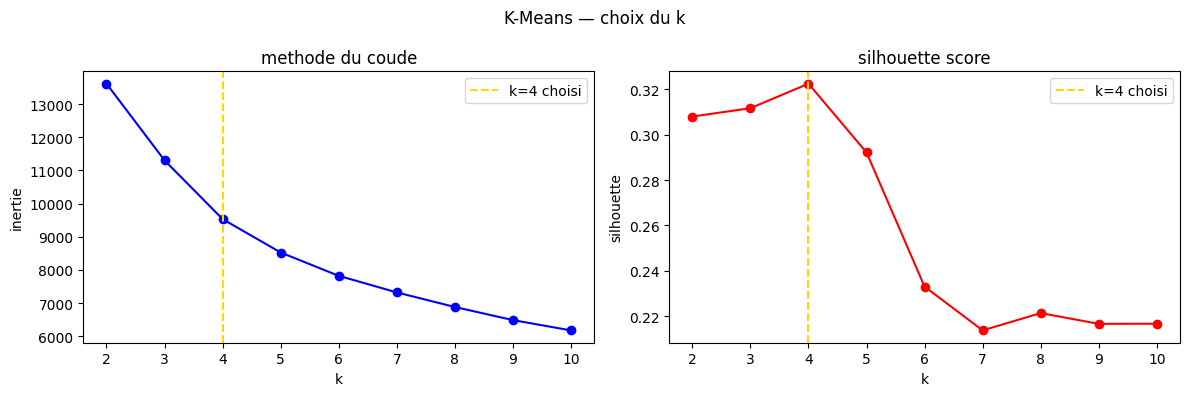

In [23]:
inertie=[]
silhouette=[]
k_range=range(2,11)
for k in k_range:
    km=KMeans(n_clusters=k,random_state=42,n_init=10)
    km.fit(X_scaled)
    inertie.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled, km.labels_))
fig,(axe1,axe2)=plt.subplots(1,2,figsize=(12,4))
axe1.plot(list(k_range),inertie,'bo-')
axe1.axvline(x=4,color='gold',linestyle='--',label='k=4 choisi')
axe1.set_xlabel('k');axe1.set_ylabel('inertie')
axe1.set_title('methode du coude');axe1.legend()

axe2.plot(list(k_range),silhouette,'ro-')
axe2.axvline(x=4,color='gold',linestyle='--',label='k=4 choisi')
axe2.set_xlabel('k');axe2.set_ylabel('silhouette')
axe2.set_title('silhouette score');axe2.legend()
plt.suptitle("K-Means — choix du k")
plt.tight_layout();plt.show()

In [24]:
kmeans= KMeans(n_clusters=4,random_state=42,n_init=10)
kmeans.fit(X_scaled)
labels_kmeans=kmeans.labels_
centres= kmeans.cluster_centers_
sil_k=silhouette_score(X_scaled,labels_kmeans)
dbi=davies_bouldin_score(X_scaled,labels_kmeans)
ch=calinski_harabasz_score(X_scaled,labels_kmeans)
print(f"silhouette score:{sil_k:.4f}")
print(f"davies-bouldin index:{dbi:.4f}")
print(f"calinski-harabasz:{ch:.1f}")
for c in range(4):
    n=(labels_kmeans == c).sum()
    print(f"cluster {c}:{n} jours ({100*n/len(labels_kmeans):.1f}%)")

silhouette score:0.3224
davies-bouldin index:1.1954
calinski-harabasz:749.1
cluster 0:963 jours (44.5%)
cluster 1:829 jours (38.3%)
cluster 2:77 jours (3.6%)
cluster 3:293 jours (13.6%)


cluster2->Hiver (temp_max moy=17.6C)
cluster1->Printemps (temp_max moy=19.3C)
cluster3->Automne (temp_max moy=24.0C)
cluster0->Ete (temp_max moy=25.3C)


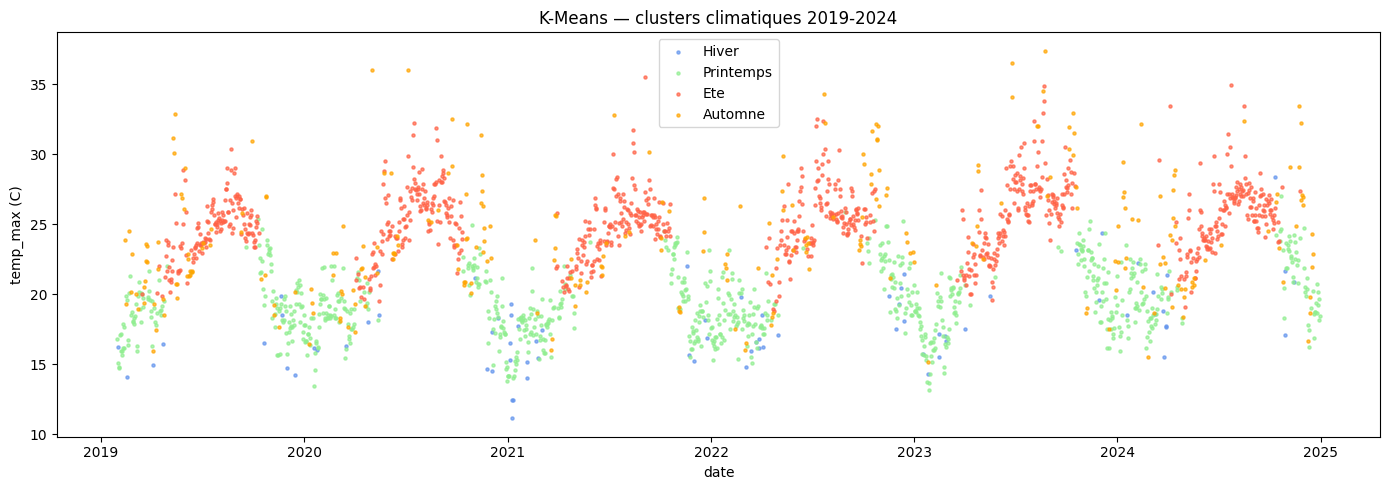

In [25]:
df_profil= X_cluster.copy()
df_profil['cluster']=labels_kmeans
profil=df_profil.groupby('cluster')[features_cluster].mean().round(2)
temp_ordre=profil['temp_max'].sort_values()
noms_clusters={}
for i,(idx, val) in enumerate(temp_ordre.items()):
    if i==0:noms_clusters[idx]='Hiver'
    elif i==1:noms_clusters[idx]='Printemps'
    elif i==2:noms_clusters[idx]='Automne'
    else:noms_clusters[idx]='Ete'
for k, v in noms_clusters.items():
    print(f"cluster{k}->{v} (temp_max moy={temp_ordre[k]:.1f}C)")
df_feat['saison_kmeans'] = pd.Series(labels_kmeans,index=X_cluster.index).map(noms_clusters)
couleurs_saisons = {'Hiver':'cornflowerblue','Printemps':'lightgreen','Ete':'tomato', 'Automne':'orange'}
df_plot = df_feat[['temp_max', 'saison_kmeans']].dropna()
plt.figure(figsize=(14, 5))
for saison,couleur in couleurs_saisons.items():
    mask = df_plot['saison_kmeans']==saison
    plt.scatter(df_plot[mask].index,df_plot[mask]['temp_max'],color=couleur, s=5, alpha=0.7, label=saison)
plt.title("K-Means — clusters climatiques 2019-2024")
plt.xlabel("date");plt.ylabel("temp_max (C)");plt.legend()
plt.tight_layout();plt.show()

# ***DBSCAN***

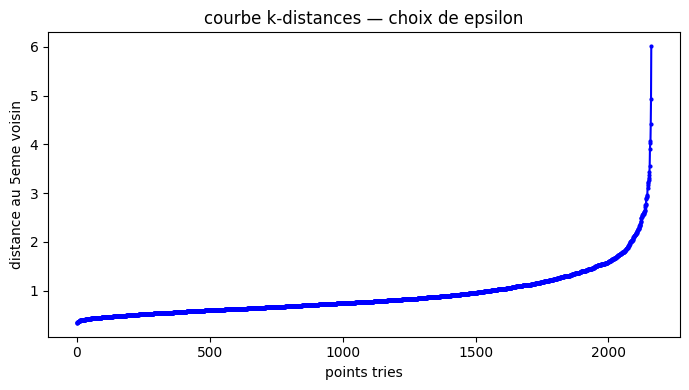

In [26]:
neighbors=NearestNeighbors(n_neighbors=5)
neighbors.fit(X_scaled)
distances, _=neighbors.kneighbors(X_scaled)
distances_5 =np.sort(distances[:, 4])

plt.figure(figsize=(7, 4))
plt.plot(distances_5, 'bo-',markersize=2)
plt.xlabel('points tries');plt.ylabel('distance au 5eme voisin')
plt.title('courbe k-distances — choix de epsilon')
plt.tight_layout();plt.show()

In [27]:
resultats_dbscan = []
for eps in [0.7, 0.8, 0.9, 1.0, 1.1]:
    for min_s in [5, 8, 10]:
        db=DBSCAN(eps=eps, min_samples=min_s)
        labels=db.fit_predict(X_scaled)
        n_clusters=len(set(labels))-(1 if -1 in labels else 0)
        n_anomalies=(labels==-1).sum()
        pct=100*n_anomalies / len(labels)
        sil_loop=-1
        if n_clusters>1:
            mask=labels!=-1
            sil_loop=round(silhouette_score(X_scaled[mask], labels[mask]),4)
        resultats_dbscan.append({'eps':eps,'min_samples':min_s,'n_clusters':n_clusters,'pct_anomalies':round(pct, 1),'silhouette':sil_loop})
df_res = pd.DataFrame(resultats_dbscan)
print(df_res.to_string())
df_valides = df_res[(df_res['n_clusters'] > 1) &(df_res['pct_anomalies'] >= 3) &(df_res['pct_anomalies'] <= 20) &(df_res['silhouette'] > 0)].sort_values('silhouette',ascending=False)
print("\ncombinations valides :")
print(df_valides.to_string())
if len(df_valides)==0:
    print("aucune combinaison valide — choix manuel : eps=1.1, min_samples=5")
    best_eps=1.1
    best_mins=5
else:
    best=df_valides.iloc[0]
    best_eps=best['eps']
    best_mins=int(best['min_samples'])
print(f"\nparams choisis : eps={best_eps}, min_samples={best_mins}")
dbscan=DBSCAN(eps=best_eps,min_samples=best_mins)
dbscan.fit(X_scaled)
labels_dbscan =dbscan.labels_
n_clusters_db=len(set(labels_dbscan))-(1 if -1 in labels_dbscan else 0)
n_anomalies_db=(labels_dbscan==-1).sum()
print(f"clusters detectes:{n_clusters_db}")
print(f"anomalies:{n_anomalies_db}({100*n_anomalies_db/len(labels_dbscan):.1f}%)")
print(f"points normaux:{(labels_dbscan >= 0).sum()}")
mask_valide = labels_dbscan != -1
if n_clusters_db>1:
    sil_db=silhouette_score(X_scaled[mask_valide],labels_dbscan[mask_valide])
    dbi_db=davies_bouldin_score(X_scaled[mask_valide],labels_dbscan[mask_valide])
    ch_db=calinski_harabasz_score(X_scaled[mask_valide],labels_dbscan[mask_valide])
    print(f"silhouette score:{sil_db:.4f}")
    print(f"davies-bouldin index:{dbi_db:.4f}")
    print(f"calinski-harabasz:{ch_db:.1f}")
else:
    print("un seul cluster->ajuster eps")

    eps  min_samples  n_clusters  pct_anomalies  silhouette
0   0.7            5           6           47.3     -0.0696
1   0.7            8           7           57.1     -0.0076
2   0.7           10           3           62.8      0.3748
3   0.8            5           2           34.0      0.2439
4   0.8            8           1           39.7     -1.0000
5   0.8           10           3           44.0     -0.0084
6   0.9            5           3           25.9      0.1516
7   0.9            8           1           29.9     -1.0000
8   0.9           10           1           32.3     -1.0000
9   1.0            5           3           20.7      0.0816
10  1.0            8           1           23.9     -1.0000
11  1.0           10           1           25.6     -1.0000
12  1.1            5           3           16.0      0.1349
13  1.1            8           1           19.1     -1.0000
14  1.1           10           1           20.6     -1.0000

combinations valides :
    eps  min_sam

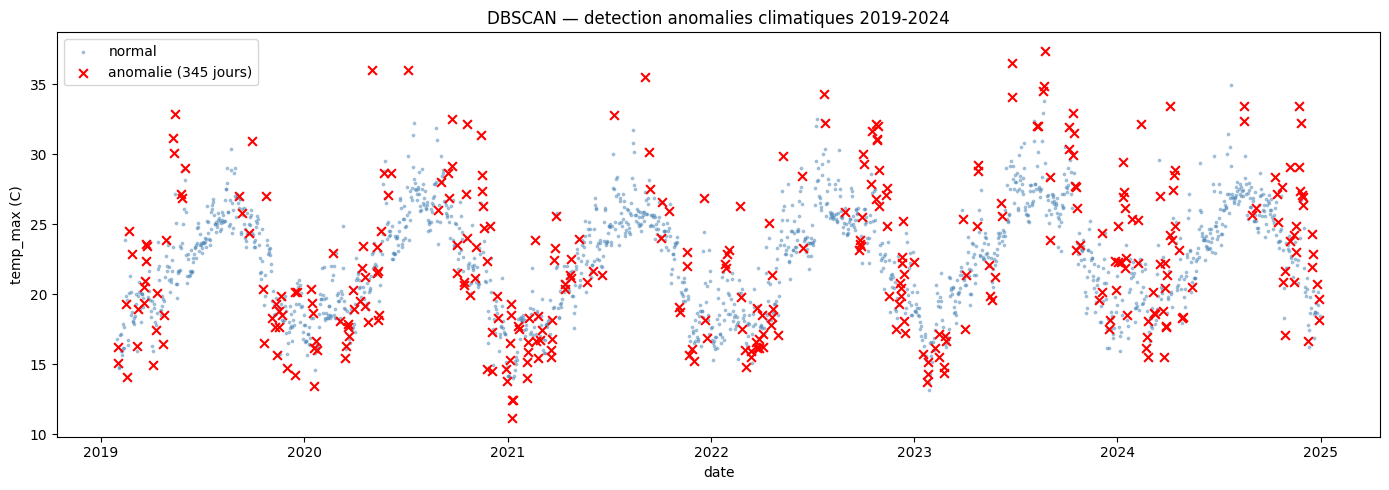

dbscan termine


In [28]:
df_feat['is_anomalie']=False
df_feat.loc[X_cluster.index,'is_anomalie']=(labels_dbscan == -1)
plt.figure(figsize=(14, 5))
mask_norm=~df_feat['is_anomalie']
mask_anom=df_feat['is_anomalie']
plt.scatter(df_feat[mask_norm].index, df_feat[mask_norm]['temp_max'],s=3,alpha=0.4,color='steelblue',label='normal')
plt.scatter(df_feat[mask_anom].index, df_feat[mask_anom]['temp_max'],s=40, color='red',marker='x',label=f'anomalie ({n_anomalies_db} jours)')
plt.title("DBSCAN — detection anomalies climatiques 2019-2024")
plt.xlabel("date");plt.ylabel("temp_max (C)");plt.legend()
plt.tight_layout();plt.show()
print("dbscan termine")

# ***PCA ***

PCA 2D  variance expliquee:65.8%


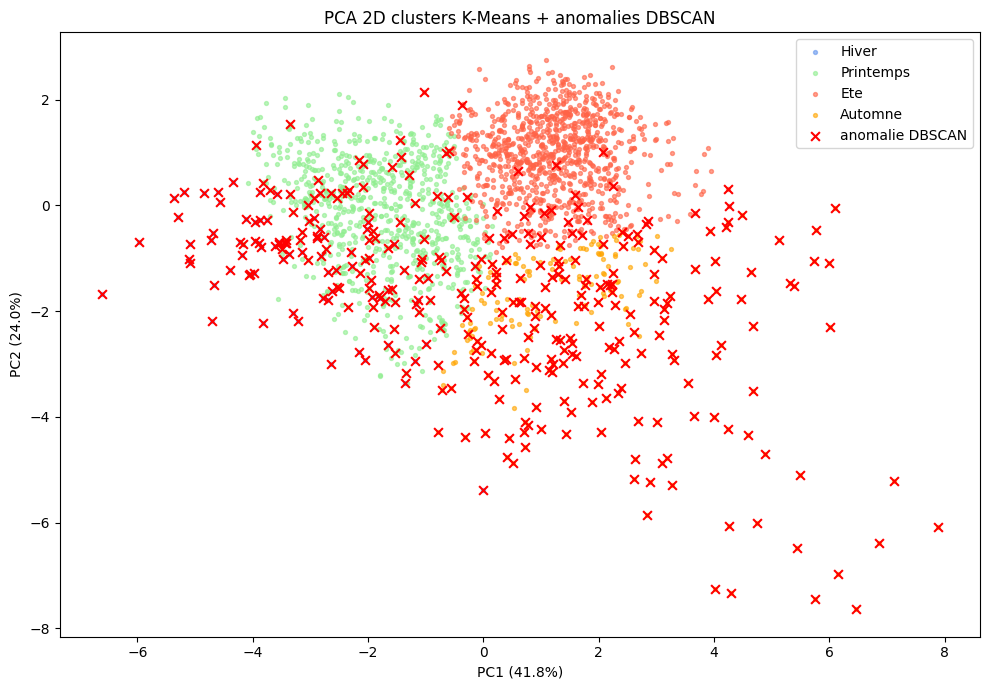

In [30]:
pca_2d=PCA(n_components=2,random_state=42)
X_pca2=pca_2d.fit_transform(X_scaled)
print(f"PCA 2D  variance expliquee:{sum(pca_2d.explained_variance_ratio_)*100:.1f}%")
cluster_name_map=np.array([noms_clusters.get(l, f"C{l}") for l in labels_kmeans])
plt.figure(figsize=(10,7))
for saison,couleur in couleurs_saisons.items():
    mask = cluster_name_map == saison
    plt.scatter(X_pca2[mask, 0],X_pca2[mask, 1],color=couleur,s=8,alpha=0.6,label=saison)
plt.scatter(X_pca2[labels_dbscan==-1, 0],X_pca2[labels_dbscan==-1,1],color='red', s=40, marker='x',label='anomalie DBSCAN',zorder=5)
plt.title("PCA 2D clusters K-Means + anomalies DBSCAN")
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend(); plt.tight_layout() ; plt.show()

In [31]:
metriques = {'K-Means'  : {'silhouette': sil_k , 'davies-bouldin': dbi, 'calinski-harabasz': ch},'DBSCAN':{'silhouette': sil_db,'davies-bouldin':dbi_db,'calinski-harabasz':ch_db},}

print("=" * 60)
print(f"{'modele':<12}{'silhouette':>12}{'davies-bouldin':>16}{'calinski':>12}")
print("=" * 60)
for nom, res in metriques.items():
    print(f"{nom:<12}{res['silhouette']:>12.4f} {res['davies-bouldin']:>16.4f} {res['calinski-harabasz']:>12.1f}")


modele        silhouette  davies-bouldin    calinski
K-Means           0.3224           1.1954        749.1
DBSCAN            0.1349           0.9154          9.4


In [32]:
def generer_alerte(temp_pred, precip, wind, humidity):
    alertes=[]
    if temp_pred>38:
        alertes.append("ALERTE CANICULE:restriction arrosage agricole recommandee")
    elif temp_pred > 33:
        alertes.append("VIGILANCE CHALEUR:surveiller stress hydrique des cultures")
    if precip > 20:
        alertes.append("ALERTE INONDATION :activer drainage urbain preventif")
    elif precip > 10:
        alertes.append("VIGILANCE PLUIE : risque ruissellement eleve")
    if wind > 40:
        alertes.append("ALERTE VENT:risque erosion des sols eleve")
    if humidity < 30 and temp_pred > 30:
        alertes.append("RISQUE SECHERESSE:indice evapotranspiration critique")
    if not alertes:
        alertes.append("CONDITIONS NORMALES:aucune action requise")
    return alertes
print("SYSTEME D ALERTE — 30 derniers jours de test")
for i in range(min(30, len(y_test))):
    date= y_test.index[i]
    temp_p= float(xgb_pred[i])
    precip= float(df_test['precipitation'].iloc[i])
    wind= float(df_test['wind_speed_max'].iloc[i])
    hum= float(df_test['humidity_mean'].iloc[i])
    alertes=generer_alerte(temp_p, precip, wind, hum)
    if alertes[0] !="CONDITIONS NORMALES : aucune action requise":
        print(f"\n{date.date()} | temp_pred={temp_p:.1f}C")
        for a in alertes:
            print(f" ->{a}")

SYSTEME D ALERTE — 30 derniers jours de test

2023-10-19 | temp_pred=28.1C
 ->ALERTE INONDATION :activer drainage urbain preventif

2023-10-20 | temp_pred=23.5C
 ->CONDITIONS NORMALES:aucune action requise

2023-10-21 | temp_pred=25.9C
 ->ALERTE VENT:risque erosion des sols eleve

2023-10-22 | temp_pred=22.4C
 ->CONDITIONS NORMALES:aucune action requise

2023-10-23 | temp_pred=22.2C
 ->CONDITIONS NORMALES:aucune action requise

2023-10-24 | temp_pred=23.5C
 ->CONDITIONS NORMALES:aucune action requise

2023-10-25 | temp_pred=23.6C
 ->CONDITIONS NORMALES:aucune action requise

2023-10-26 | temp_pred=21.2C
 ->CONDITIONS NORMALES:aucune action requise

2023-10-27 | temp_pred=23.1C
 ->CONDITIONS NORMALES:aucune action requise

2023-10-28 | temp_pred=23.0C
 ->CONDITIONS NORMALES:aucune action requise

2023-10-29 | temp_pred=24.5C
 ->CONDITIONS NORMALES:aucune action requise

2023-10-30 | temp_pred=22.6C
 ->CONDITIONS NORMALES:aucune action requise

2023-10-31 | temp_pred=22.3C
 ->CONDITIONS 

Evolution climatique annuelle — Casablanca 2019-2024
             temp_max  temp_min  precipitation  humidity_mean
date                                                         
2019-12-31  21.510000     14.28     212.399994      75.550003
2020-12-31  22.379999     15.03     264.000000      75.050003
2021-12-31  21.700001     14.65     411.399994      77.739998
2022-12-31  22.680000     15.15     313.200012      75.839996
2023-12-31  23.120001     14.86     299.399994      76.150002
2024-12-31  23.400000     14.92     330.299988      74.099998

tendance temp_max:+0.361 C/an (p=0.016)
tendance statistiquement significative


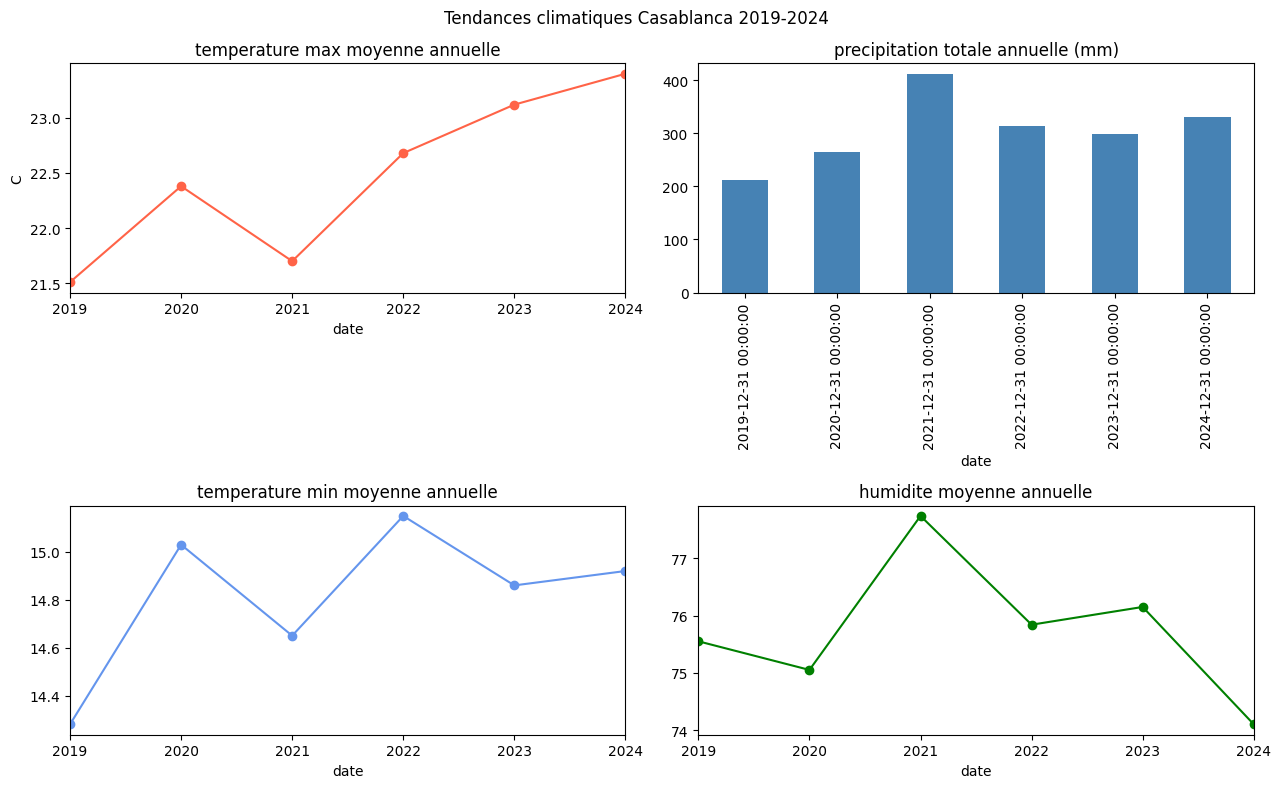

In [33]:
df_annuel=df_clean.resample('YE').agg({'temp_max':'mean','temp_min':'mean','precipitation':'sum','humidity_mean':'mean'}).round(2)
print("Evolution climatique annuelle — Casablanca 2019-2024")
print(df_annuel.to_string())
from scipy import stats
annees = np.arange(len(df_annuel))
slope, intercept, r, p, _=stats.linregress(annees,df_annuel['temp_max'])
print(f"\ntendance temp_max:{slope:+.3f} C/an (p={p:.3f})")
if p<0.05:
    print("tendance statistiquement significative")
else:
    print("tendance non significative sur 6 ans")
fig,axes=plt.subplots(2,2,figsize=(13,8))
df_annuel['temp_max'].plot(ax=axes[0,0],marker='o',color='tomato')
axes[0,0].set_title("temperature max moyenne annuelle")
axes[0,0].set_ylabel("C")
df_annuel['precipitation'].plot(ax=axes[0,1], kind='bar',color='steelblue')
axes[0,1].set_title("precipitation totale annuelle (mm)")
df_annuel['temp_min'].plot(ax=axes[1,0], marker='o', color='cornflowerblue')
axes[1,0].set_title("temperature min moyenne annuelle")
df_annuel['humidity_mean'].plot(ax=axes[1,1], marker='o', color='green')
axes[1,1].set_title("humidite moyenne annuelle")
plt.suptitle("Tendances climatiques Casablanca 2019-2024")
plt.tight_layout()
plt.show()

distribution du risque sur predictions 2024 :
Normal:410 jours
Attention:28 jours
Danger:1 jours


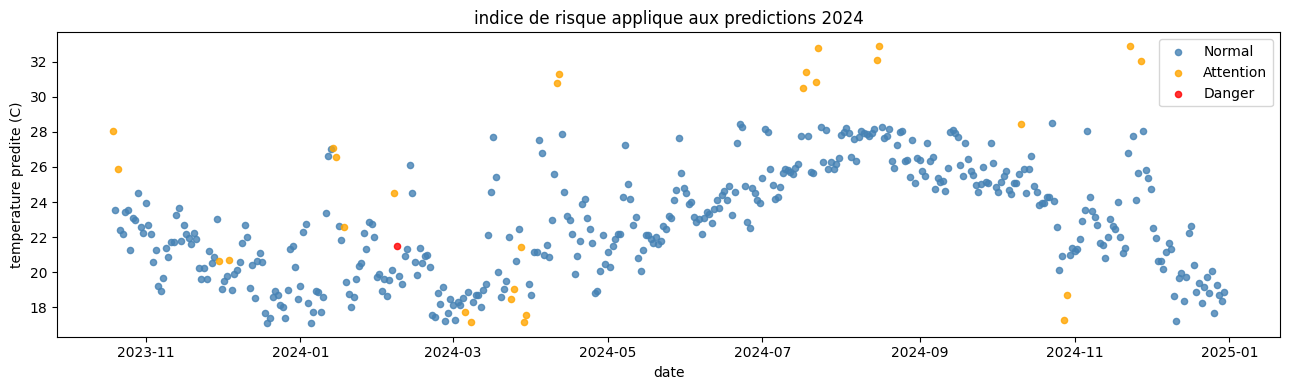

In [34]:
def compute_risk_index(row):
    score = 0
    if row['temp_max'] > 35:score += 40
    elif row['temp_max'] > 30:score += 20
    elif row['temp_max'] > 27:score += 10
    if row['precipitation'] > 15:score += 30
    elif row['precipitation'] > 5:score += 15
    elif row['precipitation'] > 1:score += 5
    if row['wind_speed_max'] > 40:score += 20
    elif row['wind_speed_max'] > 25:score += 10
    if row['humidity_mean'] < 45:score += 10
    elif row['humidity_mean'] < 55:score += 5
    if score >= 50:label ='Danger'
    elif score >= 20:label ='Attention'
    else:label ='Normal'
    return pd.Series({'risk_score':score,'risk_label':label})
df_test_original=df_feat[df_feat.index>SPLIT_DATE].copy()
df_risque_pred = pd.DataFrame({'temp_max':xgb_pred,'precipitation':df_test_original['precipitation'].values,'wind_speed_max':df_test_original['wind_speed_max'].values,'humidity_mean':df_test_original['humidity_mean'].values}, index=y_test.index)
df_risque_pred[['risk_score', 'risk_label']] = df_risque_pred.apply(compute_risk_index, axis=1)
df_risque_pred['temp_reel'] = y_test.values
dist_pred = df_risque_pred['risk_label'].value_counts()
print("distribution du risque sur predictions 2024 :")
print(f"Normal:{dist_pred.get('Normal', 0)} jours")
print(f"Attention:{dist_pred.get('Attention', 0)} jours")
print(f"Danger:{dist_pred.get('Danger', 0)} jours")
plt.figure(figsize=(13, 4))
colors_risk={'Normal':'steelblue','Attention':'orange','Danger':'red'}
for label, color in colors_risk.items():
    mask = df_risque_pred['risk_label'] == label
    plt.scatter(df_risque_pred[mask].index, df_risque_pred[mask]['temp_max'],color=color, s=20, alpha=0.8, label=label)
plt.title("indice de risque applique aux predictions 2024")
plt.xlabel("date")
plt.ylabel("temperature predite (C)")
plt.legend()
plt.tight_layout()
plt.show()